# Practical Statistics for Data Scientists (Python + R)
# Chapter 7. Unsupervised Learning
> (c) 2019 Peter C. Bruce, Andrew Bruce, Peter Gedeck


## Loading the rpy2 extension in a notebook with the Python kernel


In [1]:
import sys
import io

stderr_original = sys.stderr
sys.stderr = io.StringIO()

%load_ext rpy2.ipython

sys.stderr = stderr_original


In [2]:
%%R
suppressWarnings(
  invisible(
    try(Sys.setlocale("LC_ALL", "English"), silent = TRUE)
  )
)


## Import packages


### Import required Python packages


In [3]:
import math
from pathlib import Path
import pandas as pd
import numpy as np

from sklearn import preprocessing
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture

from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import multivariate_normal

import prince

import matplotlib.pyplot as plt
from matplotlib import cm 
from matplotlib.colors import from_levels_and_colors
import seaborn as sns

%matplotlib inline

In [4]:
try:
    import common
    DATA = common.dataDirectory()
except ImportError:
    DATA = Path().resolve() / 'data'

### Import required R packages


In [5]:
%%R
Sys.setlocale("LC_ALL", "English")
# Install missing packages if needed
packages <- c("dplyr", "tidyr", "ggplot2", "lubridate", "ellipse", "mclust", "cluster", "ca")
installed <- rownames(installed.packages())
to_install <- packages[!packages %in% installed]
if (length(to_install) > 0) {
  install.packages(to_install, repos = 'https://cloud.r-project.org/')
}

# Load them all
library(dplyr)
library(tidyr)
library(ggplot2)
library(lubridate)
library(ellipse)
library(mclust)
library(cluster)
library(ca)


Dolaczanie pakietu: 'dplyr'

Nastepujace obiekty zostaly zakryte z 'package:stats':

    filter, lag

Nastepujace obiekty zostaly zakryte z 'package:base':

    intersect, setdiff, setequal, union


Dolaczanie pakietu: 'lubridate'

Nastepujace obiekty zostaly zakryte z 'package:base':

    date, intersect, setdiff, union


Dolaczanie pakietu: 'ellipse'

Nastepujacy obiekt zostal zakryty z 'package:graphics':

    pairs

                   __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.

Dolaczanie pakietu: 'mclust'

Nastepujacy obiekt zostal zakryty z 'package:dplyr':

    count

In addition: Warning messages:
1: pakiet 'ellipse' zostal zbudowany w wersji R 4.5.3 
2: pakiet 'mclust' zostal zbudowany w wersji R 4.5.3 
3: pakiet 'ca' zostal zbudowany w wersji R 4.5.3 


## Defining data paths
If you don't keep your data in the same directory as the code, adapt the path names.

### Python

In [6]:
SP500_DATA_CSV = DATA / 'sp500_data.csv.gz'
SP500_SECTORS_CSV = DATA / 'sp500_sectors.csv'
LOAN_DATA_CSV = DATA / 'loan_data.csv.gz'
HOUSE_TASKS_CSV = DATA / 'housetasks.csv'

### R

In [7]:
%%R
PSDS_PATH <- file.path(dirname(dirname(getwd())))

sp500_px <- read.csv(file.path(PSDS_PATH, 'data', 'sp500_data.csv.gz'), row.names=1)
sp500_sym <- read.csv(file.path(PSDS_PATH, 'data', 'sp500_sectors.csv'), stringsAsFactors = FALSE)
loan_data <- read.csv(file.path(PSDS_PATH, 'data', 'loan_data.csv.gz'))
loan_data$outcome <- ordered(loan_data$outcome, levels=c('paid off', 'default'))
housetasks <- read.csv(file.path(PSDS_PATH, 'data', 'housetasks.csv'), row.names=1)

### Summary: Defining data paths

| Operation | Python | R | Notes |
|---|---|---|---|
| Base path setup | `Path(...)` / explicit strings | direct path strings in `read.csv()` | Both point to the same chapter datasets. |
| Dataset loading | `pd.read_csv(...)` | `read.csv(...)` | Equivalent import step with language-specific defaults. |
| Basic preprocessing | pandas column transforms | base R column transforms | Both align units before analysis. |

Python makes path handling and transformations explicit through objects, while R keeps data import and quick preprocessing concise.

# Principal Components Analysis
## A simple example

### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


In [8]:
sp500_px = pd.read_csv(SP500_DATA_CSV, index_col=0)
oil_px = sp500_px[['XOM', 'CVX']]
print(oil_px.head())

                 XOM       CVX
1993-01-29 -0.016991  0.072921
1993-02-01  0.016991  0.102089
1993-02-02  0.084954  0.029168
1993-02-03  0.067964  0.058337
1993-02-04  0.034378  0.044272


In [9]:
pcs = PCA(n_components=2)
pcs.fit(oil_px)
loadings = pd.DataFrame(pcs.components_, columns=oil_px.columns)
print(loadings)

        XOM       CVX
0  0.664711  0.747101
1  0.747101 -0.664711


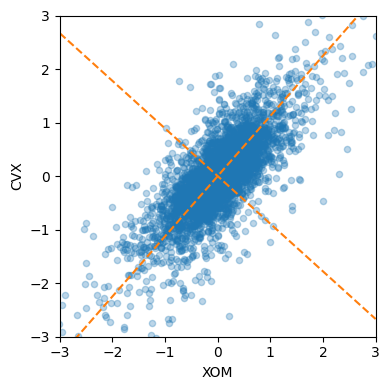

In [10]:
def abline(slope, intercept, ax):
    """Calculate coordinates of a line based on slope and intercept"""
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)

ax = oil_px.plot.scatter(x='XOM', y='CVX', alpha=0.3, figsize=(4, 4))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.plot(*abline(loadings.loc[0, 'CVX'] / loadings.loc[0, 'XOM'], 0, ax),
        '--', color='C1')
ax.plot(*abline(loadings.loc[1, 'CVX'] / loadings.loc[1, 'XOM'], 0, ax),
        '--', color='C1')

plt.tight_layout()
plt.show()

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.

In [11]:
%%R
oil_px <- sp500_px[, c('CVX', 'XOM')]
pca <- princomp(oil_px)
pca$loadings


Loadings:
    Comp.1 Comp.2
CVX  0.747  0.665
XOM  0.665 -0.747

               Comp.1 Comp.2
SS loadings       1.0    1.0
Proportion Var    0.5    0.5
Cumulative Var    0.5    1.0


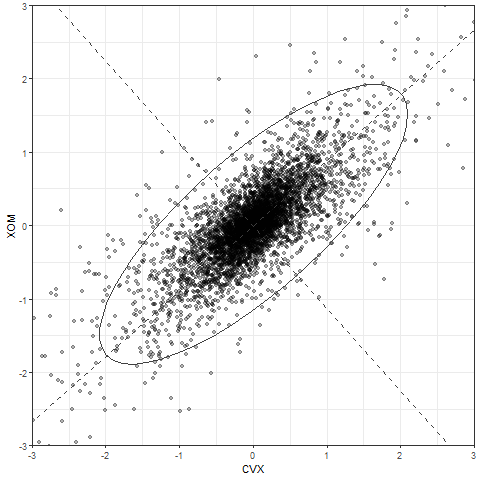

In [12]:
%%R
loadings <- pca$loadings
graph <- ggplot(data=oil_px, aes(x=CVX, y=XOM)) +
  geom_point(alpha=.3) +
  scale_shape_manual(values=c(46)) +
  stat_ellipse(type='norm', level=.99, color='grey25') +
  geom_abline(intercept = 0, slope = loadings[2,1]/loadings[1,1], color='grey25', linetype=2) +
  geom_abline(intercept = 0, slope = loadings[2,2]/loadings[1,2],  color='grey25', linetype=2) +
  scale_x_continuous(expand=c(0,0)) + 
  scale_y_continuous(expand=c(0,0)) +
  coord_cartesian(xlim=c(-3, 3), ylim=c(-3, 3)) +
  theme_bw()
graph

### Summary: Principal Components Analysis

| Operation | Python | R | Notes |
|---|---|---|---|
| PCA fit | `sklearn.decomposition.PCA` | `princomp`/`prcomp` | Both reduce dimensionality using orthogonal components. |
| Scores/loadings | component arrays in pandas/NumPy | `scores`/`loadings` extraction | Equivalent interpretation of latent directions. |
| Visualization | matplotlib scatter/loadings | ggplot PCA visuals | Both inspect structure in low-dimensional space. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


## Interpreting principal components


### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


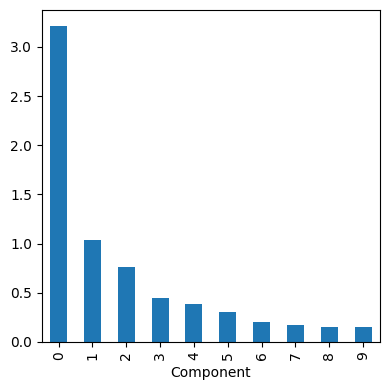

In [13]:
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
        'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]

sp_pca = PCA()
sp_pca.fit(top_sp)

explained_variance = pd.DataFrame(sp_pca.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

plt.tight_layout()
plt.show()

In [14]:
loadings = pd.DataFrame(sp_pca.components_[0:5, :], 
                        columns=top_sp.columns)
print(loadings)

       AAPL       AXP       COP      COST      CSCO       CVX        HD  \
0  0.300825  0.246332  0.261529  0.273634  0.064059  0.444490  0.207983   
1  0.505116  0.139426 -0.174212  0.416307  0.031939 -0.289373  0.278002   
2  0.786730 -0.135458  0.002367 -0.465862  0.007524 -0.082374 -0.166320   
3 -0.120586  0.061814 -0.206026  0.092596  0.003904 -0.577665  0.162814   
4 -0.111576  0.596666  0.005813 -0.555529  0.039860 -0.109016  0.185488   

       INTC       JPM      MSFT       SLB       TGT       USB       WFC  \
0  0.076956  0.196397  0.105012  0.481786  0.148833  0.116421  0.145684   
1  0.033898  0.040723  0.053954 -0.472494  0.228123  0.054796  0.047427   
2  0.003518 -0.062261 -0.016248  0.194822 -0.160833 -0.048976 -0.041932   
3 -0.001605  0.057687 -0.012558  0.680914  0.109895  0.016752  0.018614   
4  0.072047  0.385160  0.077135 -0.181332  0.055557  0.155440  0.216425   

        WMT       XOM  
0  0.122304  0.317952  
1  0.222889 -0.154192  
2 -0.175806 -0.090167  
3 

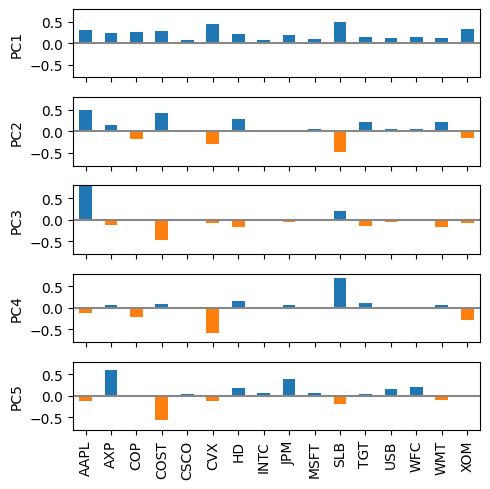

In [15]:
maxPC = 1.01 * loadings.loc[0:5, :].abs().to_numpy().max()

f, axes = plt.subplots(5, 1, figsize=(5, 5), sharex=True)

for i, ax in enumerate(axes):
    pc_loadings = loadings.loc[i, :]
    colors = ['C0' if l > 0 else 'C1' for l in pc_loadings]
    ax.axhline(color='#888888')
    pc_loadings.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'PC{i+1}')
    ax.set_ylim(-maxPC, maxPC)

plt.tight_layout()
plt.show()

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


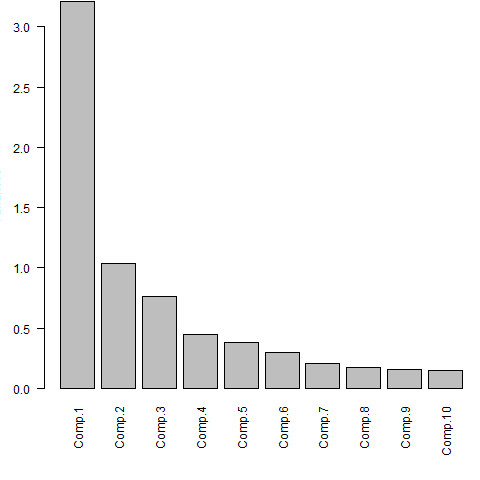

In [16]:
%%R
syms <- c( 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
           'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST')
top_sp <- sp500_px[row.names(sp500_px)>='2011-01-01', syms]
sp_pca <- princomp(top_sp)
par(mar=c(6,3,0,0)+.1, las=2)
screeplot(sp_pca, main='')

In [17]:
%%R
loadings <- sp_pca$loadings[,1:5]
loadings <- as.data.frame(loadings)
loadings$Symbol <- row.names(loadings)
loadings <- gather(loadings, 'Component', 'Weight', -Symbol)

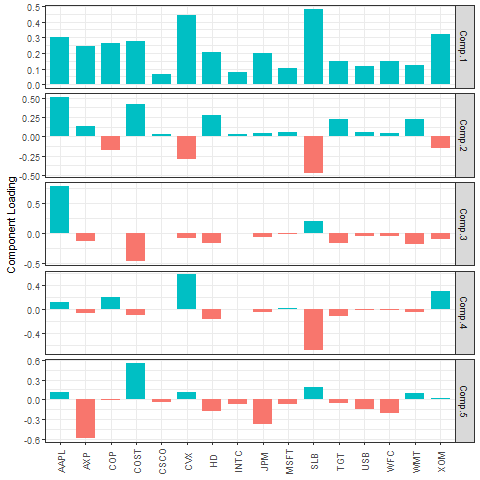

In [18]:
%%R
loadings$Color = loadings$Weight > 0
graph <- ggplot(loadings, aes(x=Symbol, y=Weight, fill=Color)) +
  geom_bar(stat='identity', position='identity', width=.75) + 
  facet_grid(Component ~ ., scales='free_y') +
  guides(fill='none') +
  ylab('Component Loading') +
  theme_bw() +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_text(angle=90, vjust=0.5))
graph

### Summary: Interpreting principal components

| Operation | Python | R | Notes |
|---|---|---|---|
| Top loading review | sorted loadings in DataFrame | loading matrices and summaries | Both identify dominant variables per component. |
| Component meaning | manual sign/magnitude interpretation | manual sign/magnitude interpretation | Same interpretive process. |
| Plot annotation | matplotlib text overlays | ggplot annotation layers | Equivalent explanatory plotting patterns. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


## Correspondence analysis


### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


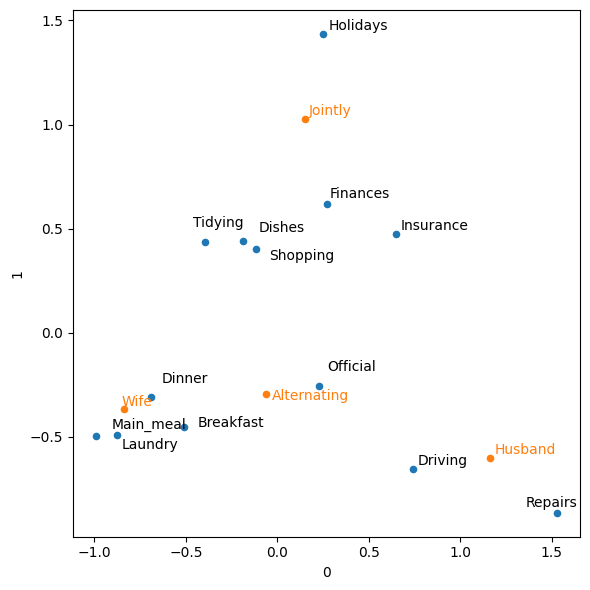

In [19]:
from adjustText import adjust_text

housetasks = pd.read_csv(HOUSE_TASKS_CSV, index_col=0)

ca = prince.CA(n_components=2)
ca = ca.fit(housetasks)

ax = ca.row_coordinates(housetasks).plot.scatter(x=0, y=1, figsize=(6,6))
ca.column_coordinates(housetasks).plot.scatter(x=0, y=1, ax=ax, c='C1')
texts = []
for idx, row in ca.row_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx))
for idx, row in ca.column_coordinates(housetasks).iterrows():
    texts.append(plt.text(row[0], row[1], idx, color='C1'))
adjust_text(texts, only_move={'points':'y', 'texts':'y'}) 
plt.tight_layout()
plt.show()

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


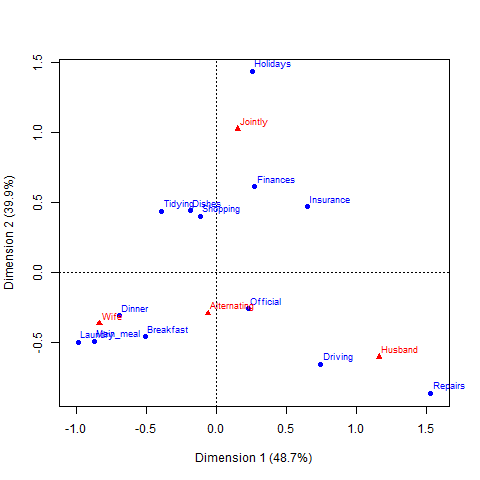

In [20]:
%%R
ca_analysis <- ca(housetasks)
plot(ca_analysis)

In [21]:
%%R
if (!require(ggrepel)) {
    install.packages("ggrepel",
                 repos = "https://cloud.r-project.org",
                 dependencies = TRUE,
                 quiet = TRUE)
    library(ggrepel)
}

Ladowanie wymaganego pakietu: ggrepel
In addition: Warning message:
pakiet 'ggrepel' zostal zbudowany w wersji R 4.5.3 


In [22]:
%%R
ca_analysis$sv ** 2
summary(ca_analysis)


Principal inertias (eigenvalues):

 dim    value      %   cum%   scree plot               
 1      0.542889  48.7  48.7  ************             
 2      0.445003  39.9  88.6  **********               
 3      0.127048  11.4 100.0  ***                      
        -------- -----                                 
 Total: 1.114940 100.0                                 


Rows:
     name   mass  qlt  inr    k=1 cor ctr    k=2 cor ctr  
1  | Lndr |  101  925  120 | -992 740 183 | -495 185  56 |
2  | Mn_m |   88  974   81 | -876 742 124 | -490 232  47 |
3  | Dnnr |   62  930   34 | -693 777  55 | -308 154  13 |
4  | Brkf |   80  905   37 | -509 505  38 | -453 400  37 |
5  | Tdyn |   70  975   22 | -394 440  20 |  434 535  30 |
6  | Dshs |   65  764   18 | -189 118   4 |  442 646  28 |
7  | Shpp |   69  811   13 | -118  64   2 |  403 748  25 |
8  | Offc |   55  119   48 |  227  53   5 | -254  66   8 |
9  | Drvn |   80  767   91 |  742 432  81 | -653 335  76 |
10 | Fnnc |   65  997   27 |  

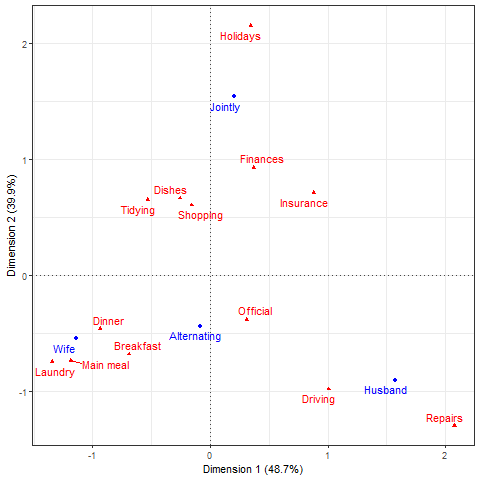

In [23]:
%%R
contrib = ca_analysis$sv ** 2
contrib = contrib / sum(contrib)
colcoord = as.data.frame(ca_analysis$colcoord)
rowcoord = as.data.frame(ca_analysis$rowcoord)
coords = rbind(
    cbind(rowcoord, type='rowcoord'),
    cbind(colcoord, type='columns')
)
row.names(coords) <- gsub('_', ' ', row.names(coords))

graph <- ggplot(coords, aes(x=Dim1, y=Dim2, color=type, label=rownames(coords), shape=type)) +
    geom_hline(yintercept=0, linetype='dotted', color='#444444') + 
    geom_vline(xintercept = 0, linetype='dotted', color='#444444') +
    geom_point() +
    geom_text_repel() + 
    xlab(sprintf('Dimension 1 (%.1f%%)', 100 * contrib[1])) +
    ylab(sprintf('Dimension 2 (%.1f%%)', 100 * contrib[2])) +
    scale_color_manual(values = c('blue', 'red')) +
    theme_bw() +
    theme(legend.position = "none") 
graph

### Summary: Correspondence analysis

| Operation | Python | R | Notes |
|---|---|---|---|
| CA computation | `prince.CA()` | `ca::ca()` | Both map categorical association to low-dimensional coordinates. |
| Category map | biplot-style coordinate display | biplot-style coordinate display | Same interpretation of proximity and association. |
| Output use | coordinate tables + plots | coordinate tables + plots | Equivalent exploratory objective. |

Python uses the `prince` library which follows a scikit-learn estimator interface, while R uses the dedicated `ca` package with its own plotting conventions.

# K-Means Clustering
## A Simple Example

### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


In [24]:
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
kmeans = KMeans(n_clusters=4, n_init='auto').fit(df)
df['cluster'] = kmeans.labels_
print(df.head())

                 XOM       CVX  cluster
2011-01-03  0.736805  0.240681        2
2011-01-04  0.168668 -0.584516        1
2011-01-05  0.026631  0.446985        2
2011-01-06  0.248558 -0.919751        1
2011-01-07  0.337329  0.180511        2


In [25]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['XOM', 'CVX'])
print(centers)

        XOM       CVX
0  0.927032  1.346412
1 -0.330814 -0.574398
2  0.231540  0.316965
3 -1.144397 -1.757796


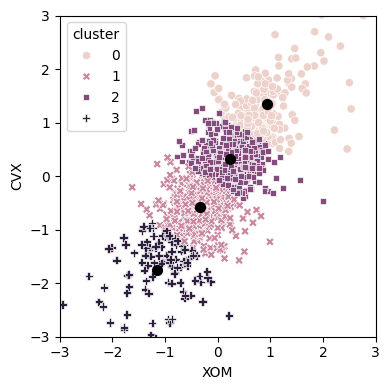

In [26]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.scatterplot(x='XOM', y='CVX', hue='cluster', style='cluster', 
                     ax=ax, data=df)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
centers.plot.scatter(x='XOM', y='CVX', ax=ax, s=50, color='black')

plt.tight_layout()
plt.show()

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


In [27]:
%%R
set.seed(1010103)
df <- sp500_px[row.names(sp500_px)>='2011-01-01', c('XOM', 'CVX')]
km <- kmeans(df, centers=4, nstart=1)

df$cluster <- factor(km$cluster)
head(df)

                  XOM        CVX cluster
2011-01-03 0.73680496  0.2406809       1
2011-01-04 0.16866845 -0.5845157       4
2011-01-05 0.02663055  0.4469854       1
2011-01-06 0.24855834 -0.9197513       4
2011-01-07 0.33732892  0.1805111       1
2011-01-10 0.00000000 -0.4641675       4


In [28]:
%%R
centers <- data.frame(cluster=factor(1:4), km$centers)
centers

  cluster        XOM        CVX
1       1  0.2315403  0.3169645
2       2  0.9270317  1.3464117
3       3 -1.1439800 -1.7502975
4       4 -0.3287416 -0.5734695


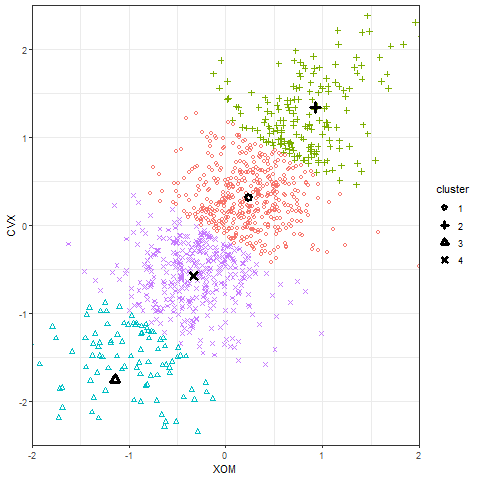

In [29]:
%%R
graph <- ggplot(data=df, aes(x=XOM, y=CVX, color=cluster, shape=cluster)) +
  geom_point() +
  scale_shape_manual(values = c(1, 3, 2, 4),
                     guide = guide_legend(override.aes=aes(size=1))) + 
  geom_point(data=centers,  aes(x=XOM, y=CVX), size=2, stroke=2, color='black')  +
  theme_bw() +
  scale_x_continuous(expand=c(0,0)) + 
  scale_y_continuous(expand=c(0,0)) +
  coord_cartesian(xlim=c(-2, 2), ylim=c(-2.5, 2.5))

graph

### Summary: K-Means Clustering

| Operation | Python | R | Notes |
|---|---|---|---|
| Model fit | `KMeans` | `kmeans` | Both partition observations into centroid-based clusters. |
| Cluster labels | `labels_` | `cluster` | Equivalent assignment outputs. |
| Centroids | `cluster_centers_` | `centers` | Both provide centroid profiles for interpretation. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


## K-Means Algorithm


### Python
The _scikit-learn_ algorithm is repeated 10 times by default (`n_init`), `max_iter` is used to control the number of iterations. 

In [30]:
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP', 
               'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])
top_sp = sp500_px.loc[sp500_px.index >= '2011-01-01', syms]
kmeans = KMeans(n_clusters=5, n_init='auto').fit(top_sp)

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


In [31]:
%%R
syms <- c( 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
           'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST')
df <- sp500_px[row.names(sp500_px) >= '2011-01-01', syms]

set.seed(10010)
km <- kmeans(df, centers=5, nstart=10)

### Summary: K-Means Algorithm

| Operation | Python | R | Notes |
|---|---|---|---|
| Initialization | random/seeding controls | random/seeding controls | Both depend on initialization and local minima. |
| Iteration | fit loop in estimator | fit loop in function | Equivalent reassign-update process. |
| Convergence | inertia/iteration diagnostics | tot.withinss/iteration diagnostics | Same objective minimization logic. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


## Interpreting the Clusters


### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


In [32]:
from collections import Counter
print(Counter(kmeans.labels_))

Counter({np.int32(0): 303, np.int32(2): 270, np.int32(4): 260, np.int32(1): 159, np.int32(3): 139})


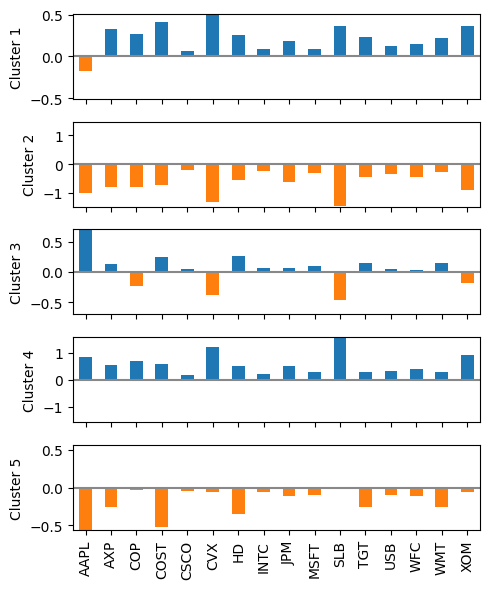

In [33]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=syms)

f, axes = plt.subplots(5, 1, figsize=(5, 6), sharex=True)
for i, ax in enumerate(axes):
    center = centers.loc[i, :]
    maxPC = 1.01 * np.max(np.max(np.abs(center)))
    colors = ['C0' if l > 0 else 'C1' for l in center]
    ax.axhline(color='#888888')
    center.plot.bar(ax=ax, color=colors)
    ax.set_ylabel(f'Cluster {i + 1}')
    ax.set_ylim(-maxPC, maxPC)

plt.tight_layout()
plt.show()

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


In [34]:
%%R
km$size

[1] 288 266 285 106 186


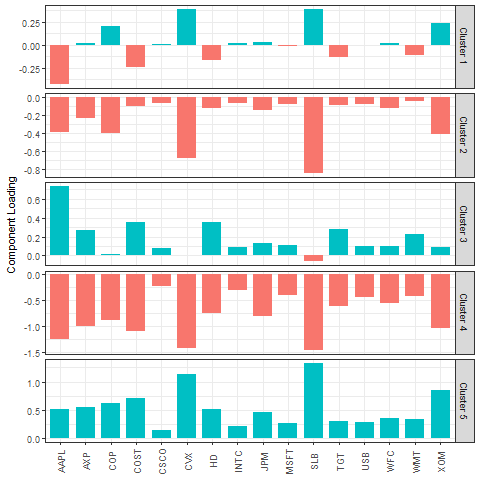

In [35]:
%%R
centers <- as.data.frame(t(km$centers))
names(centers) <- paste('Cluster', 1:5)
centers$Symbol <- row.names(centers)
centers <- gather(centers, 'Cluster', 'Mean', -Symbol)

centers$Color = centers$Mean > 0
graph <- ggplot(centers, aes(x=Symbol, y=Mean, fill=Color)) +
  geom_bar(stat='identity', position='identity', width=.75) + 
  facet_grid(Cluster ~ ., scales='free_y') +
  guides(fill='none')  +
  ylab('Component Loading') +
  theme_bw() +
  theme(axis.title.x=element_blank(),
        axis.text.x=element_text(angle=90, vjust=0.5))
graph

### Summary: Interpreting the Clusters

| Operation | Python | R | Notes |
|---|---|---|---|
| Cluster profiling | grouped summaries in pandas | grouped summaries in dplyr | Both build human-readable cluster descriptions. |
| Visualization | scatter/centroid overlays | ggplot cluster plots | Equivalent cluster-separation inspection. |
| Business meaning | manual profile interpretation | manual profile interpretation | Same interpretation workflow. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


## Selecting the Number of Clusters


### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


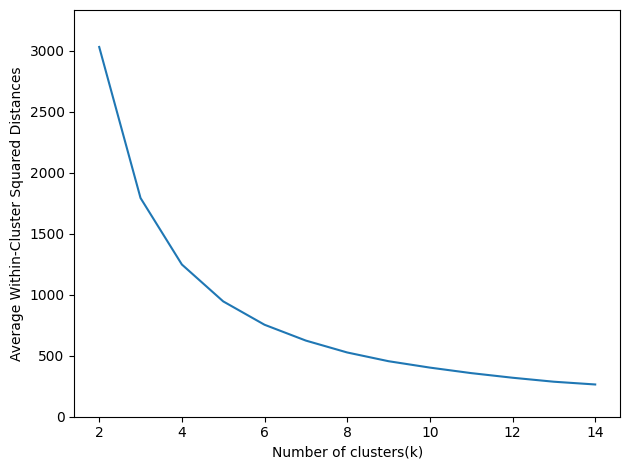

In [36]:
inertia = []
for n_clusters in range(2, 15):
    kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init='auto').fit(top_sp)
    inertia.append(kmeans.inertia_ / n_clusters)
inertias = pd.DataFrame({'n_clusters': range(2, 15), 'inertia': inertia})
ax = inertias.plot(x='n_clusters', y='inertia')
plt.xlabel('Number of clusters(k)')
plt.ylabel('Average Within-Cluster Squared Distances')
plt.ylim((0, 1.1 * inertias.inertia.max()))
ax.legend().set_visible(False)

plt.tight_layout()
plt.show()

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


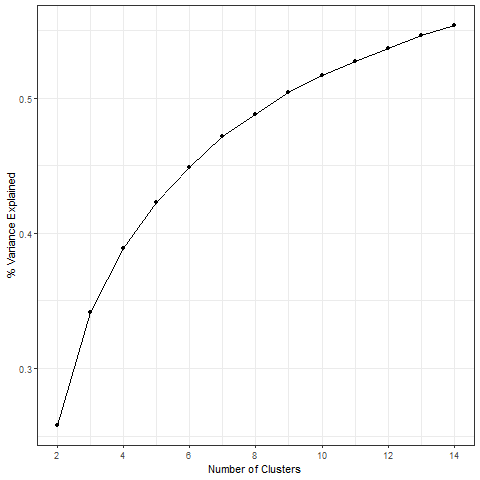

In [37]:
%%R
pct_var <- data.frame(pct_var = 0,
                      num_clusters=2:14)
totalss <- kmeans(df, centers=14, nstart=50, iter.max=100)$totss
for (i in 2:14) {
  kmCluster <- kmeans(df, centers=i, nstart=50, iter.max = 100)
  pct_var[i-1, 'pct_var'] <- kmCluster$betweenss / totalss
}

graph <- ggplot(pct_var, aes(x=num_clusters, y=pct_var)) +
  geom_line() +
  geom_point() +
  labs(y='% Variance Explained', x='Number of Clusters') +
  scale_x_continuous(breaks=seq(2, 14, by=2))   +
  theme_bw()
graph

### Summary: Selecting the Number of Clusters

| Operation | Python | R | Notes |
|---|---|---|---|
| Elbow/scree | inertia vs k | withinss vs k | Both inspect diminishing returns with larger k. |
| Alternative criteria | silhouette/gap-style checks | silhouette/gap-style checks | Equivalent model-selection intent. |
| Final choice | tradeoff between fit and simplicity | tradeoff between fit and simplicity | Same practical selection criterion. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


# Hierarchical Clustering
## A Simple Example

### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.

In [38]:
syms1 = ['AAPL', 'AMZN', 'AXP', 'COP', 'COST', 'CSCO', 'CVX', 'GOOGL', 'HD', 
         'INTC', 'JPM', 'MSFT', 'SLB', 'TGT', 'USB', 'WFC', 'WMT', 'XOM']
df = sp500_px.loc[sp500_px.index >= '2011-01-01', syms1].transpose()

Z = linkage(df, method='complete')
print(Z.shape)

(17, 4)


### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


In [39]:
%%R
syms1 <- c('GOOGL', 'AMZN', 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 
           'XOM', 'SLB', 'COP', 'JPM', 'WFC', 'USB', 'AXP',
           'WMT', 'TGT', 'HD', 'COST')

df <- sp500_px[row.names(sp500_px) >= '2011-01-01', syms1]
d <- dist(t(df))
hcl <- hclust(d)

### Summary: Hierarchical Clustering

| Operation | Python | R | Notes |
|---|---|---|---|
| Distance matrix | pairwise distance computation | `dist(...)` | Both start from dissimilarity matrices. |
| Linkage | `linkage`/cluster tools | `hclust` | Equivalent agglomerative merging process. |
| Cluster cut | threshold-based cut | `cutree` | Same way to derive final clusters. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


## The Dendrogram


### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


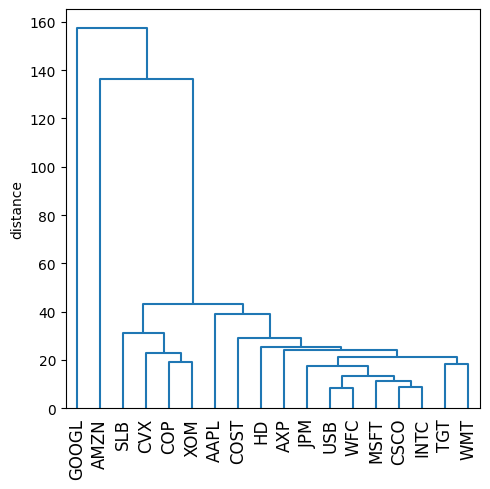

In [40]:
fig, ax = plt.subplots(figsize=(5, 5))
dendrogram(Z, labels=list(df.index), color_threshold=0)
plt.xticks(rotation=90)
ax.set_ylabel('distance')

plt.tight_layout()
plt.show()

In [41]:
memb = fcluster(Z, 4, criterion='maxclust')
memb = pd.Series(memb, index=df.index)
for key, item in memb.groupby(memb):
    print(f"{key} : {', '.join(item.index)}")

1 : COP, CVX, SLB, XOM
2 : AAPL, AXP, COST, CSCO, HD, INTC, JPM, MSFT, TGT, USB, WFC, WMT
3 : AMZN
4 : GOOGL


### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


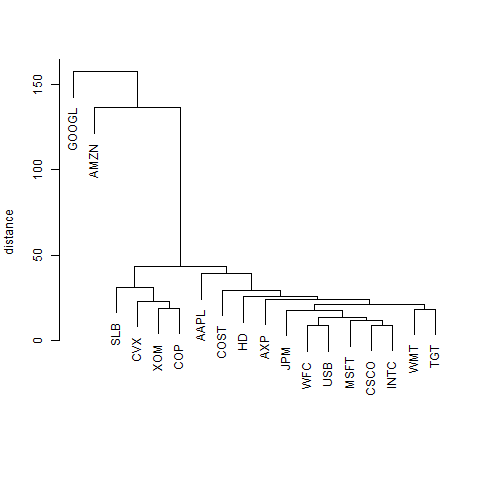

In [42]:
%%R
plot(hcl, ylab='distance', xlab='', sub='', main='')

In [43]:
%%R
cutree(hcl, k=4)

GOOGL  AMZN  AAPL  MSFT  CSCO  INTC   CVX   XOM   SLB   COP   JPM   WFC   USB 
    1     2     3     3     3     3     4     4     4     4     3     3     3 
  AXP   WMT   TGT    HD  COST 
    3     3     3     3     3 


### Summary: The Dendrogram

| Operation | Python | R | Notes |
|---|---|---|---|
| Tree visualization | dendrogram plotting in Python | dendrogram plotting in R | Both show nested merge hierarchy. |
| Cut level | horizontal cutoff interpretation | horizontal cutoff interpretation | Equivalent group-count control. |
| Outlier branches | branch-length inspection | branch-length inspection | Same structure diagnostics. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


## Measures of Dissimilarity


### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


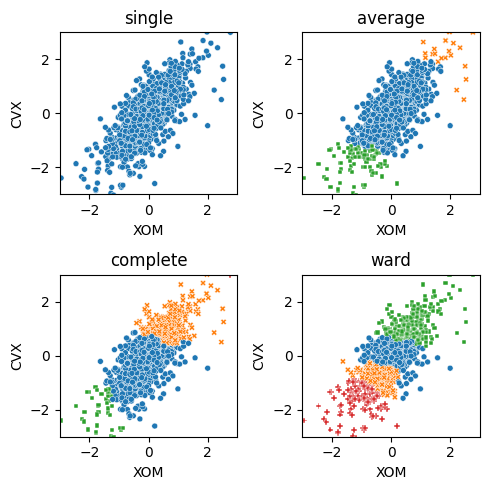

In [44]:
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(5, 5))
for i, method in enumerate(['single', 'average', 'complete', 'ward']):
    ax = axes[i // 2, i % 2]
    Z = linkage(df, method=method)
    colors = [f'C{c+1}' for c in fcluster(Z, 4, criterion='maxclust')]
    ax = sns.scatterplot(x='XOM', y='CVX', hue=colors, style=colors,
                         size=0.5, ax=ax, data=df, legend=False)

    ax.set_xlim(-3, 3)
    ax.set_ylim(-3, 3)
    ax.set_title(method)

plt.tight_layout()
plt.show()

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


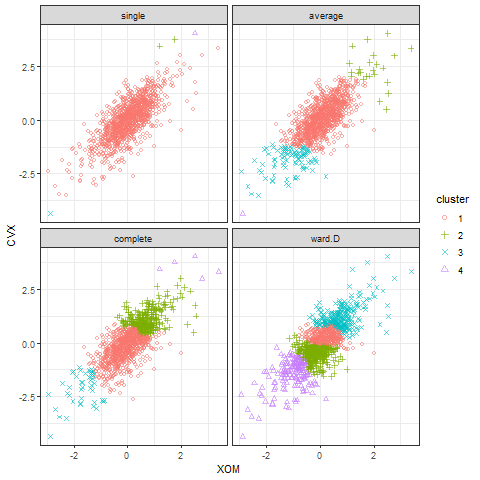

In [45]:
%%R
cluster_fun <- function(df, method)
{
  d <- dist(df)
  hcl <- hclust(d, method=method)
  tree <- cutree(hcl, k=4)
  df$cluster <- factor(tree)
  df$method <- method
  return(df)
}

df0 <- sp500_px[row.names(sp500_px) >= '2011-01-01', c('XOM', 'CVX')]
df <- rbind(cluster_fun(df0, method='single'),
            cluster_fun(df0, method='average'),
            cluster_fun(df0, method='complete'),
            cluster_fun(df0, method='ward.D'))
df$method <- ordered(df$method, c('single', 'average', 'complete', 'ward.D'))

graph <- ggplot(data=df, aes(x=XOM, y=CVX, color=cluster, shape=cluster)) +
  geom_point(alpha=0.6) +
  scale_shape_manual(values=c(1, 3, 4, 2),
                     guide=guide_legend(override.aes=aes(size=2))) +
  facet_wrap( ~ method) +
  theme_bw()
graph

### Summary: Measures of Dissimilarity

| Operation | Python | R | Notes |
|---|---|---|---|
| Distance types | euclidean/manhattan/etc. | euclidean/manhattan/etc. | Both allow metric choice based on data geometry. |
| Scaling impact | pre-scaling before distance | pre-scaling before distance | Same sensitivity to feature scale. |
| Downstream effect | changes hierarchy/cluster assignment | changes hierarchy/cluster assignment | Equivalent methodological implication. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


# Model based clustering
## Multivariate Normal Distribution
> Define a colormap that corresponds to the probability levels

### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


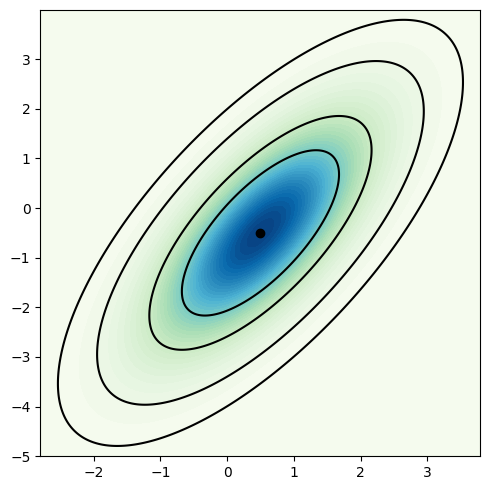

In [46]:
mean = [0.5, -0.5]
cov = [[1, 1], [1, 2]]
probability = [.5, .75, .95, .99]
def probLevel(p):
    D = 1
    return (1 - p) / (2 * math.pi * D)
levels = [probLevel(p) for p in probability]

fig, ax = plt.subplots(figsize=(5, 5))

x, y = np.mgrid[-2.8:3.8:.01, -5:4:.01]
pos = np.empty(x.shape + (2,))
pos[:, :, 0] = x; pos[:, :, 1] = y
rv = multivariate_normal(mean, cov)


CS = ax.contourf(x, y, rv.pdf(pos), cmap=cm.GnBu, levels=50)
ax.contour(CS, levels=levels, colors=['black'])
ax.plot(*mean, color='black', marker='o')


plt.tight_layout()
plt.show()

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


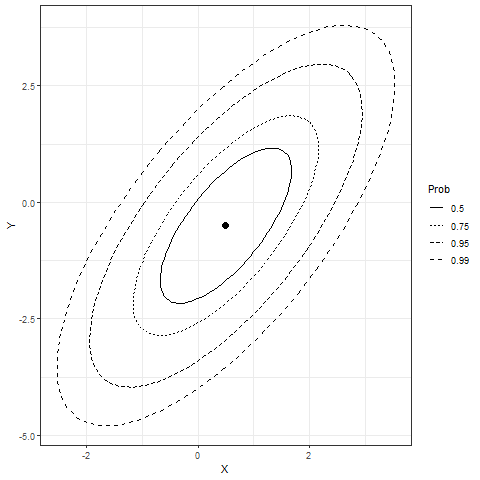

In [47]:
%%R
mu <- c(.5, -.5)
sigma <- matrix(c(1, 1, 1, 2), nrow=2)
prob <- c(.5, .75, .95, .99) ## or whatever you want
names(prob) <- prob ## to get id column in result
x <- NULL
for (p in prob){
  x <- rbind(x,  ellipse(x=sigma, centre=mu, level=p))
}
df <- data.frame(x, prob=factor(rep(prob, rep(100, length(prob)))))
names(df) <- c('X', 'Y', 'Prob')

## Figure 7-9: Multivariate normal ellipses
dfmu <- data.frame(X=mu[1], Y=mu[2])

graph <- ggplot(df, aes(X, Y)) + 
  geom_path(aes(linetype=Prob)) +
  geom_point(data=dfmu, aes(X, Y), size=3) +
  theme_bw()
graph

### Summary: Model based clustering

| Operation | Python | R | Notes |
|---|---|---|---|
| Probabilistic clustering | `sklearn.mixture.GaussianMixture` | `mclust::Mclust()` | Both treat clusters as latent distributions. |
| Soft assignments | posterior probabilities | posterior probabilities | Both provide uncertainty-aware membership. |
| Model selection | manual: user specifies `n_components` | automatic: `Mclust` selects k and covariance type via BIC | Equivalent complexity control. |

Mclust automatically tests multiple covariance structures and numbers of components, selecting the best model by BIC. GaussianMixture requires the user to specify both n_components and covariance_type explicitly.

## Mixtures of Normals


### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


In [48]:
df = sp500_px.loc[sp500_px.index >= '2011-01-01', ['XOM', 'CVX']]
mclust = GaussianMixture(n_components=2).fit(df)
print(mclust.bic(df))

4589.320317053261


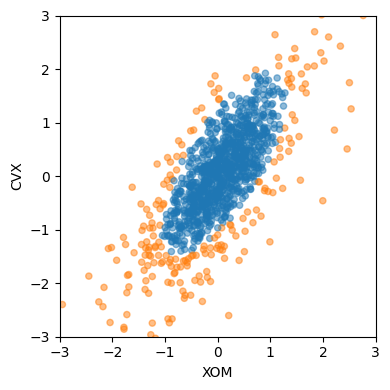

In [49]:
fig, ax = plt.subplots(figsize=(4, 4))
colors = [f'C{c}' for c in mclust.predict(df)]
df.plot.scatter(x='XOM', y='CVX', c=colors, alpha=0.5, ax=ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

plt.tight_layout()
plt.show()

In [50]:
print('Mean')
print(mclust.means_)
print('Covariances')
print(mclust.covariances_)

Mean
[[ 0.0709161   0.10228006]
 [-0.05074943 -0.21539465]]
Covariances
[[[0.27074158 0.27800893]
  [0.27800893 0.5212865 ]]

 [[0.98668327 0.99350046]
  [0.99350046 1.69695919]]]


### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


In [51]:
%%R
df <- sp500_px[row.names(sp500_px)>='2011-01-01', c('XOM', 'CVX')]
mcl <- Mclust(df)
summary(mcl)

fitting ...
  |======================================================================| 100%
---------------------------------------------------- 
Gaussian finite mixture model fitted by EM algorithm 
---------------------------------------------------- 

Mclust VEE (ellipsoidal, equal shape and orientation) model with 2 components: 

 log-likelihood    n df       BIC       ICL
      -2255.125 1131  9 -4573.528 -5075.657

Clustering table:
  1   2 
168 963 


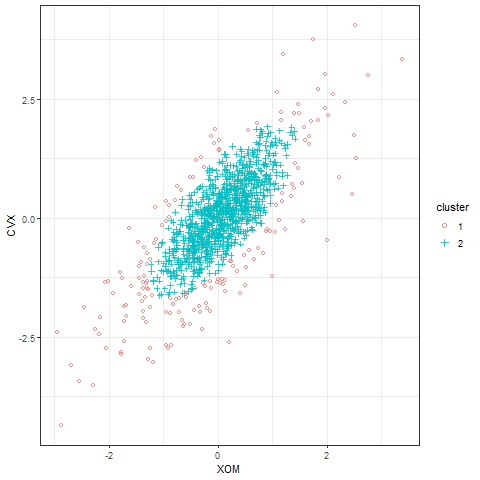

In [52]:
%%R
cluster <- factor(predict(mcl)$classification)
graph <- ggplot(data=df, aes(x=XOM, y=CVX, color=cluster, shape=cluster)) +
  geom_point(alpha=.8) +
  theme_bw() +
  scale_shape_manual(values = c(1, 3),
                     guide = guide_legend(override.aes=aes(size=2))) 
graph

In [53]:
%%R
summary(mcl, parameters=TRUE)$mean
summary(mcl, parameters=TRUE)$variance[,,1]
summary(mcl, parameters=TRUE)$variance[,,2]

          XOM       CVX
XOM 0.2998935 0.3057838
CVX 0.3057838 0.5490920


### Summary: Mixtures of Normals

| Operation | Python | R | Notes |
|---|---|---|---|
| Gaussian mixtures | `GaussianMixture(n_components=2).fit(df)` | `Mclust(df)` | Both model clusters with normal components. |
| Component params | `means_`, `covariances_` attributes | `summary(mcl, parameters=TRUE)$mean` / `$variance` | Equivalent parameter interpretation. |
| Assignment | `predict(df)` → class labels | `predict(mcl)$classification` | Same classification rule. |

Python exposes component parameters as direct object attributes, while R wraps them in a summary call with named list elements.

## Selecting the number of clusters


### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


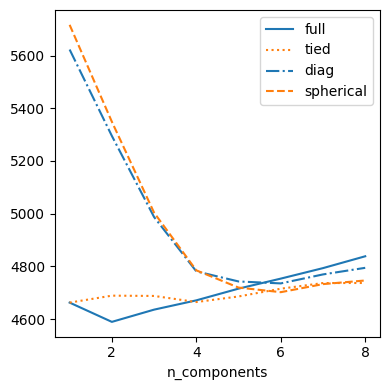

In [54]:
results = []
covariance_types = ['full', 'tied', 'diag', 'spherical']
for n_components in range(1, 9):
    for covariance_type in covariance_types:
        mclust = GaussianMixture(n_components = n_components, warm_start=True,
                                 covariance_type = covariance_type)
        mclust.fit(df)
        results.append({
            'bic': mclust.bic(df),
            'n_components': n_components,
            'covariance_type': covariance_type,
        })
        
results = pd.DataFrame(results)

colors = ['C0', 'C1', 'C2', 'C3']
styles = ['C0-','C1:','C0-.', 'C1--']

fig, ax = plt.subplots(figsize=(4, 4))
for i, covariance_type in enumerate(covariance_types):
    subset = results.loc[results.covariance_type == covariance_type, :]
    subset.plot(x='n_components', y='bic', ax=ax, label=covariance_type, 
                kind='line', style=styles[i]) # , color=colors[i])

plt.tight_layout()
plt.show()

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


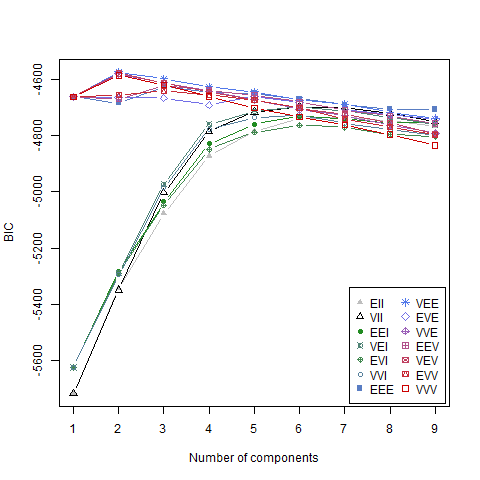

In [55]:
%%R
plot(mcl, what='BIC', ask=FALSE, cex=.75)

### Summary: Selecting the number of clusters

| Operation | Python | R | Notes |
|---|---|---|---|
| Information criteria | manual BIC loop over `n_components` × `covariance_type grid` | automatic BIC across model families inside `Mclust` | Python requires explicit grid search; R searches internally. |
| Stability checks | `warm_start=True` across repeated fits | built into `Mclust` model comparison | Equivalent robustness assessment with different ergonomics.|
| Chosen k | minimum `mclust.bic(df)` from results table | best BIC from `plot(mcl, what='BIC')` | Same selection principle, different workflow verbosity. |

Python makes the model-selection search fully explicit and inspectable, while R encapsulates it — useful shortcut but less transparent about what combinations were evaluated.

# Scaling and Categorical Variables
## Scaling the Variables

### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


In [56]:
loan_data = pd.read_csv(LOAN_DATA_CSV)
loan_data['outcome'] = pd.Categorical(loan_data['outcome'], 
                                      categories=['paid off', 'default'], 
                                      ordered=True)
defaults = loan_data.loc[loan_data['outcome'] == 'default',]

columns = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 
           'dti', 'revol_util']

df = defaults[columns]
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df)
counts = Counter(kmeans.labels_)

centers = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
centers['size'] = [counts[i] for i in range(4)]
print(centers)

      loan_amnt     annual_inc     revol_bal   open_acc        dti  \
0  17809.760881   78669.452556  18933.405997  11.594003  17.016428   
1  21444.318867  148736.057263  33152.689572  12.376733  13.831145   
2  24290.909091  409746.465909  84710.988636  13.431818   8.148636   
3  10274.160906   41241.205530   9950.095008   9.480338  17.718588   

   revol_util   size  
0   62.183810   7906  
1   63.151084   1654  
2   60.015647     88  
3   57.903425  13023  


In [57]:
scaler = preprocessing.StandardScaler()
df0 = scaler.fit_transform(df * 1.0)

kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df0)
counts = Counter(kmeans.labels_)

centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                       columns=columns)
centers['size'] = [counts[i] for i in range(4)]
print(centers)

      loan_amnt     annual_inc     revol_bal   open_acc        dti  \
0  13484.728906   55907.993263  16435.803337  14.322265  24.211535   
1  25950.205142  116834.142232  32945.972921  12.396335  16.165914   
2  10507.283093   51117.994063  11635.285252   7.509513  15.931561   
3  10324.846369   53456.824767   6054.819926   8.664618  11.312983   

   revol_util  size  
0   59.463608  6244  
1   66.123542  3670  
2   77.795077  7397  
3   30.999874  5360  


### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


In [58]:
%%R
defaults <- loan_data[loan_data$outcome=='default',]
df <- defaults[, c('loan_amnt', 'annual_inc', 'revol_bal', 'open_acc', 'dti', 'revol_util')]
km <- kmeans(df, centers=4, nstart=10)
centers <- data.frame(size=km$size, km$centers) 
print(round(centers, digits=2))

   size loan_amnt annual_inc revol_bal open_acc   dti revol_util
1    52  22570.19  489783.40  85161.35    13.33  6.91      59.65
2 13819  10577.04   42380.98  10245.27     9.58 17.71      58.09
3  1221  21797.26  164503.32  38652.54    12.61 13.53      63.65
4  7579  18247.71   83069.61  19587.30    11.66 16.79      62.26


In [59]:
%%R
df0 <- scale(df)
km0 <- kmeans(df0, centers=4, nstart=10)
centers0 <- scale(km0$centers, center=FALSE, scale=1/attr(df0, 'scaled:scale'))
centers0 <- scale(centers0, center=-attr(df0, 'scaled:center'), scale=FALSE)
centers0 <- data.frame(size=km0$size, centers0) 
print(round(centers0, digits=2))

  size loan_amnt annual_inc revol_bal open_acc   dti revol_util
1 7352  10469.87   51123.20  11525.60     7.48 15.79      77.73
2 6299  13363.49   55586.54  16363.84    14.24 24.22      59.59
3 3713  25892.73  116197.49  32803.62    12.41 16.22      66.15
4 5307  10356.29   53539.85   6037.84     8.68 11.30      30.72


In [60]:
%%R
km <- kmeans(df, centers=4, nstart=10)
centers <- data.frame(size=km$size, km$centers) 
round(centers, digits=2)

   size loan_amnt annual_inc revol_bal open_acc   dti revol_util
1 13902  10606.48   42500.30  10280.52     9.59 17.71      58.11
2  1192  21856.38  165473.54  38935.88    12.61 13.48      63.67
3    52  22570.19  489783.40  85161.35    13.33  6.91      59.65
4  7525  18282.25   83458.11  19653.82    11.66 16.77      62.27


### Summary: Scaling and Categorical Variables

| Operation | Python | R | Notes |
|---|---|---|---|
| Mixed-type prep | scaling + encoding strategy | scaling + encoding strategy | Both need careful preprocessing for mixed variables. |
| Distance choice | mixed-data distance workflow | mixed-data distance workflow | Equivalent effect on clustering quality. |
| Cluster interpretation | numeric + categorical profile review | numeric + categorical profile review | Same interpretation challenge. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


## Dominant Variables


### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


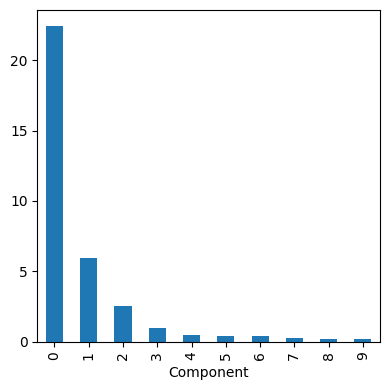

In [61]:
syms = ['GOOGL', 'AMZN', 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 
        'SLB', 'COP', 'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST']
top_sp1 = sp500_px.loc[sp500_px.index >= '2005-01-01', syms]

sp_pca1 = PCA()
sp_pca1.fit(top_sp1)

explained_variance = pd.DataFrame(sp_pca1.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

plt.tight_layout()
plt.show()

In [62]:
loadings = pd.DataFrame(sp_pca1.components_[0:2, :], 
                        columns=top_sp1.columns)
print(loadings.transpose())

              0         1
GOOGL  0.857310 -0.477873
AMZN   0.444728  0.874149
AAPL   0.071627  0.020802
MSFT   0.036002  0.006204
CSCO   0.029205  0.003045
INTC   0.026666  0.006069
CVX    0.089548  0.037420
XOM    0.080336  0.020511
SLB    0.110218  0.030356
COP    0.057739  0.024117
JPM    0.071228  0.009244
WFC    0.053228  0.008597
USB    0.041670  0.005952
AXP    0.078907  0.024027
WMT    0.040346  0.007141
TGT    0.063659  0.024662
HD     0.051412  0.032922
COST   0.071403  0.033826


### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


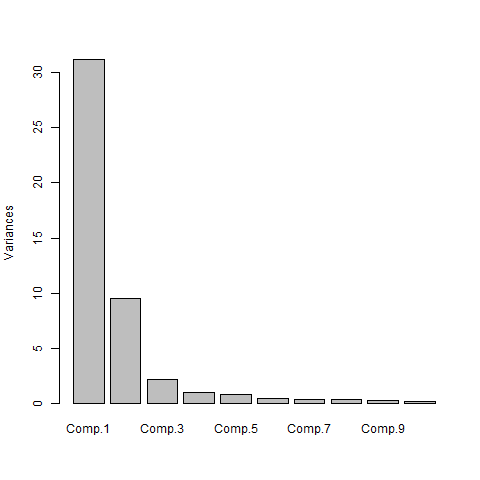

In [63]:
%%R
syms <- c('GOOGL', 'AMZN', 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 
          'SLB', 'COP', 'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST')
top_15 <- sp500_px[row.names(sp500_px)>='2011-01-01', syms]
sp_pca1 <- princomp(top_15)

screeplot(sp_pca1, main='')

In [64]:
%%R
round(sp_pca1$loadings[,1:2], 3)

      Comp.1 Comp.2
GOOGL  0.781  0.609
AMZN   0.593 -0.792
AAPL   0.078  0.004
MSFT   0.029  0.002
CSCO   0.017 -0.001
INTC   0.020 -0.001
CVX    0.068 -0.021
XOM    0.053 -0.005
SLB    0.079 -0.013
COP    0.044 -0.016
JPM    0.043  0.001
WFC    0.034 -0.001
USB    0.026  0.003
AXP    0.063 -0.006
WMT    0.026 -0.001
TGT    0.036 -0.010
HD     0.051 -0.019
COST   0.061 -0.019


### Summary: Dominant Variables

| Operation | Python | R | Notes |
|---|---|---|---|
| Dominance detection | variance/range diagnostics | variance/range diagnostics | Both identify variables that overwhelm distance. |
| Mitigation | rescaling/weighting | rescaling/weighting | Equivalent corrective strategies. |
| Validation | before/after cluster comparison | before/after cluster comparison | Same sanity-check workflow. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


## Categorical Data and Gower's Distance


### Python
> Currently not available in any of the standard packages. However work is in progress to add it to scikit-learn. We will update this notebook once it becomes available

https://github.com/scikit-learn/scikit-learn/pull/9555/

In [65]:
x = defaults[['dti', 'payment_inc_ratio', 'home_', 'purpose_']].loc[0:4, :]
print(x)

     dti  payment_inc_ratio home_            purpose_
0   1.00            2.39320  RENT      major_purchase
1   5.55            4.57170   OWN      small_business
2  18.08            9.71600  RENT               other
3  10.08           12.21520  RENT  debt_consolidation
4   7.06            3.90888  RENT               other


```

###############################################################
## Figure 7-13: Categorical data and Gower's distance

x <- loan_data[1:5, c('dti', 'payment_inc_ratio', 'home_', 'purpose_')]
x

daisy(x, metric='gower')

set.seed(301)
df <- loan_data[sample(nrow(loan_data), 250),
                c('dti', 'payment_inc_ratio', 'home_', 'purpose_')]
d = daisy(df, metric='gower')
hcl <- hclust(d)
dnd <- as.dendrogram(hcl)

png(filename=file.path(PSDS_PATH, 'figures', 'psds_0713.png'), width = 4, height=4, units='in', res=300)
par(mar=c(0,5,0,0)+.1)
plot(dnd, leaflab='none', ylab='distance')
dev.off()

dnd_cut <- cut(dnd, h=.5)
df[labels(dnd_cut$lower[[1]]),]


## Problems in clustering with mixed data types
df <- model.matrix(~ -1 + dti + payment_inc_ratio + home_ + pub_rec_zero, data=defaults)
df0 <- scale(df)
km0 <- kmeans(df0, centers=4, nstart=10)
centers0 <- scale(km0$centers, center=FALSE, scale=1/attr(df0, 'scaled:scale'))
round(scale(centers0, center=-attr(df0, 'scaled:center'), scale=FALSE), 2)
```

### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


In [66]:
%%R
x <- loan_data[1:5, c('dti', 'payment_inc_ratio', 'home_', 'purpose_')] %>%
  mutate(home_=as.factor(home_), purpose_=as.factor(purpose_))
x

    dti payment_inc_ratio home_           purpose_
1  1.00           2.39320  RENT     major_purchase
2  5.55           4.57170   OWN     small_business
3 18.08           9.71600  RENT              other
4 10.08          12.21520  RENT debt_consolidation
5  7.06           3.90888  RENT              other


In [67]:
%%R
daisy(x, metric='gower')

Dissimilarities :
          1         2         3         4
2 0.6220479                              
3 0.6863877 0.8143398                    
4 0.6329040 0.7608561 0.4307083          
5 0.3772789 0.5389727 0.3091088 0.5056250

Metric :  mixed ;  Types = I, I, N, N 
Number of objects : 5


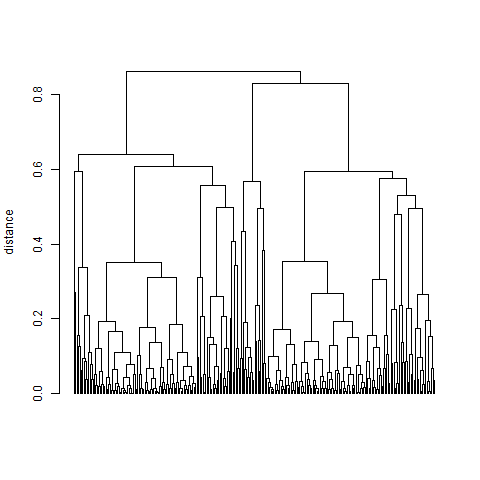

In [68]:
%%R
set.seed(301)
df <- loan_data[sample(nrow(loan_data), 250),
                c('dti', 'payment_inc_ratio', 'home_', 'purpose_')] %>%
  mutate(home_=as.factor(home_), purpose_=as.factor(purpose_))
d = daisy(df, metric='gower')
hcl <- hclust(d)
dnd <- as.dendrogram(hcl)
plot(dnd, leaflab='none', ylab='distance')

In [69]:
%%R
dnd_cut <- cut(dnd, h=.5)
df[labels(dnd_cut$lower[[4]]),]

        dti payment_inc_ratio    home_ purpose_
17286 19.79          16.55380 MORTGAGE    other
21988 10.36          14.34780 MORTGAGE    other
24706  5.59           3.83713 MORTGAGE    other
26082  1.18           2.94380 MORTGAGE    other
9840  26.12           4.90231 MORTGAGE    other
37913 19.78           5.24341 MORTGAGE    other
31884 19.65           5.16189 MORTGAGE    other


### Summary: Categorical Data and Gower's Distance

| Operation | Python | R | Notes |
|---|---|---|---|
| Gower distance | Python mixed-distance implementation | `daisy(..., metric='gower')` | Both support mixed numeric/categorical similarity. |
| Input handling | encoded + normalized fields | factor-aware mixed data | Equivalent preprocessing objective. |
| Clustering | distance-matrix based clustering | distance-matrix based clustering | Same downstream usage. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.


## Problems with Clustering Mixed Data


### Python
Python implements this section with NumPy/pandas/sklearn plotting and modeling tools.


In [70]:
columns = ['dti', 'payment_inc_ratio', 'home_', 'pub_rec_zero']
df = pd.get_dummies(defaults[columns])

scaler = preprocessing.StandardScaler()

df0 = scaler.fit_transform(df * 1.0)
kmeans = KMeans(n_clusters=4, random_state=1, n_init='auto').fit(df0)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                       columns=df.columns)
print(centers)

         dti  payment_inc_ratio  pub_rec_zero  home__MORTGAGE     home__OWN  \
0  21.431365          12.354001      0.943315    1.243450e-14 -1.401657e-15   
1  12.743276           5.918701      0.900372    1.304512e-14 -3.330669e-16   
2  17.339786           8.353535      0.905716    1.000000e+00  2.969847e-15   
3  17.197993           9.266666      0.917903   -2.331468e-15  1.000000e+00   

     home__RENT  
0  1.000000e+00  
1  1.000000e+00  
2  9.658940e-15  
3 -2.164935e-15  


### R
R reproduces the same section objective using formula-oriented statistical packages and graphics.


In [71]:
%%R
df <- model.matrix(~ -1 + dti + payment_inc_ratio + home_ + pub_rec_zero, data=defaults)
df0 <- scale(df)
km0 <- kmeans(df0, centers=4, nstart=10)
centers0 <- scale(km0$centers, center=FALSE, scale=1/attr(df0, 'scaled:scale'))
round(scale(centers0, center=-attr(df0, 'scaled:center'), scale=FALSE), 2)

    dti payment_inc_ratio home_MORTGAGE home_OWN home_RENT pub_rec_zero
1 16.99              9.11          0.00        0      1.00         1.00
2 17.20              9.27          0.00        1      0.00         0.92
3 17.46              8.42          1.00        0      0.00         1.00
4 16.50              8.06          0.52        0      0.48         0.00
attr(,"scaled:scale")
              dti payment_inc_ratio     home_MORTGAGE          home_OWN 
        0.1305561         0.2286345         2.0190809         3.6191450 
        home_RENT      pub_rec_zero 
        2.0008117         3.5722842 
attr(,"scaled:center")
              dti payment_inc_ratio     home_MORTGAGE          home_OWN 
      -17.1521684        -8.7700843        -0.4313440        -0.0832782 
        home_RENT      pub_rec_zero 
       -0.4853778        -0.9142958 


### Summary: Problems with Clustering Mixed Data

| Operation | Python | R | Notes |
|---|---|---|---|
| Type imbalance | numeric/categorical influence mismatch | numeric/categorical influence mismatch | Both face weighting trade-offs. |
| Interpretability | heterogeneous cluster profiles | heterogeneous cluster profiles | Same interpretation complexity. |
| Practical remedy | feature engineering and scaling | feature engineering and scaling | Equivalent pragmatic mitigation. |

Python emphasizes explicit data structures and estimator objects, while R emphasizes concise statistical workflows and formula-centric tooling.
